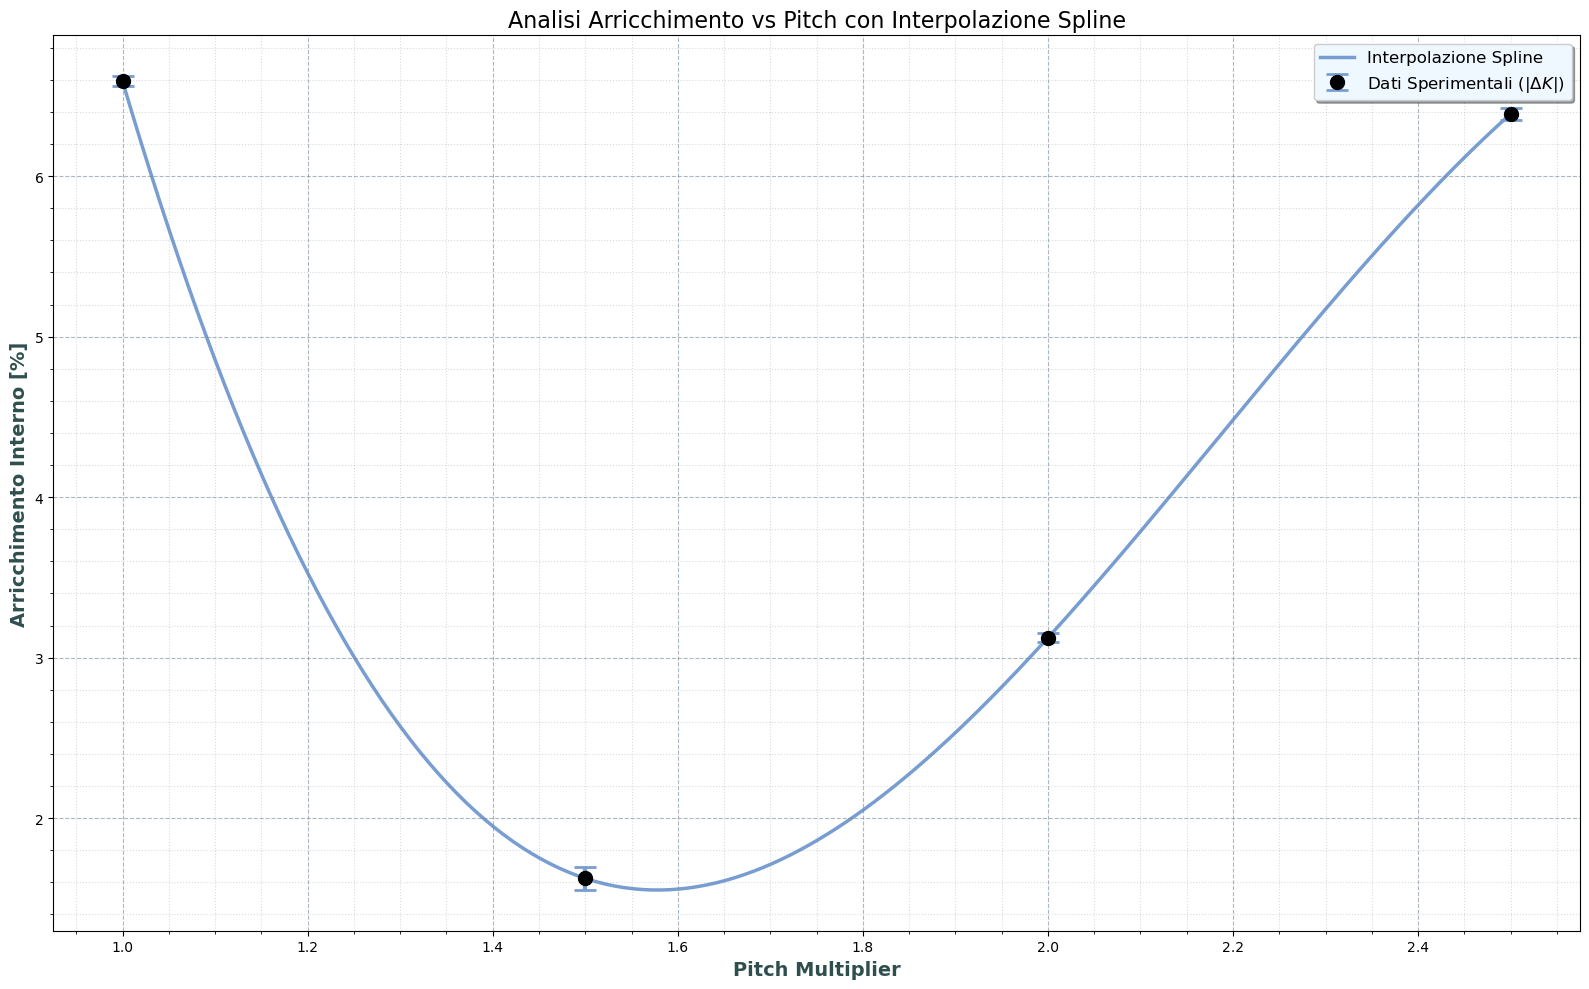

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.interpolate import make_interp_spline

# 1. Caricamento e Parsing dei dati
file_path = 'result_final.txt'

with open(file_path, 'r') as f:
    content = f.read()

# Pulizia e estrazione
clean_text = re.sub(r'\\', '', content)
numbers = re.findall(r"[-+]?\d*\.\d+|\d+", clean_text)
float_numbers = [float(x) for x in numbers]

# Mapping dati (12 colonne)
data_points = float_numbers[5:]
records = [data_points[i:i+12] for i in range(0, len(data_points), 12)]

columns = [
    'Pres', 'Pitch', 'PERC_water', 'Arricch_INT', 'Arricch_EXTT', 
    'T_WATER', 'T_FUEL', 'K_max', 'std_k_max', 'K_auto', 'std_k_auto', 'Compat'
]
df = pd.DataFrame(records, columns=columns).sort_values(by='Pitch')

# Calcolo errore
df['err_k'] = np.abs(df['K_auto'] - df['K_max'])*100

# 2. Interpolazione Spline
# Generazione di punti densi per una curva fluida
x_smooth = np.linspace(df['Pitch'].min(), df['Pitch'].max(), 300)
spl = make_interp_spline(df['Pitch'], df['Arricch_INT'], k=3)
y_smooth = spl(x_smooth)

# 3. Plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Plot della Spline (Stile Summer Cool)
ax.plot(x_smooth, y_smooth, color='#789DD1', linewidth=2.5, label='Interpolazione Spline', zorder=1)

# Barre d'errore (Point: #000000, Error Bar: #789DD1)
# Incremento visibilità: elinewidth aumentata e capsize marcato
ax.errorbar(df['Pitch'], df['Arricch_INT'], yerr=df['err_k'], 
            fmt='o', color='#000000', ecolor='#789DD1', 
            elinewidth=3, capthick=2, capsize=8, markersize=10,
            label=r'Dati Sperimentali ($|\Delta K|$)', zorder=2)


# Configurazione Assi e Titoli
ax.set_xlabel('Pitch Multiplier', fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel('Arricchimento Interno [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_title('Analisi Arricchimento vs Pitch con Interpolazione Spline', fontsize=16)

# Configurazione Grid
ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(True, which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()